In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt, patches
from pathlib import Path
import random

In [2]:
from utils import OCT5kDataset

o = OCT5kDataset()

In [3]:
OCT5kDataset.classes()

['AMD', 'DME', 'Normal']

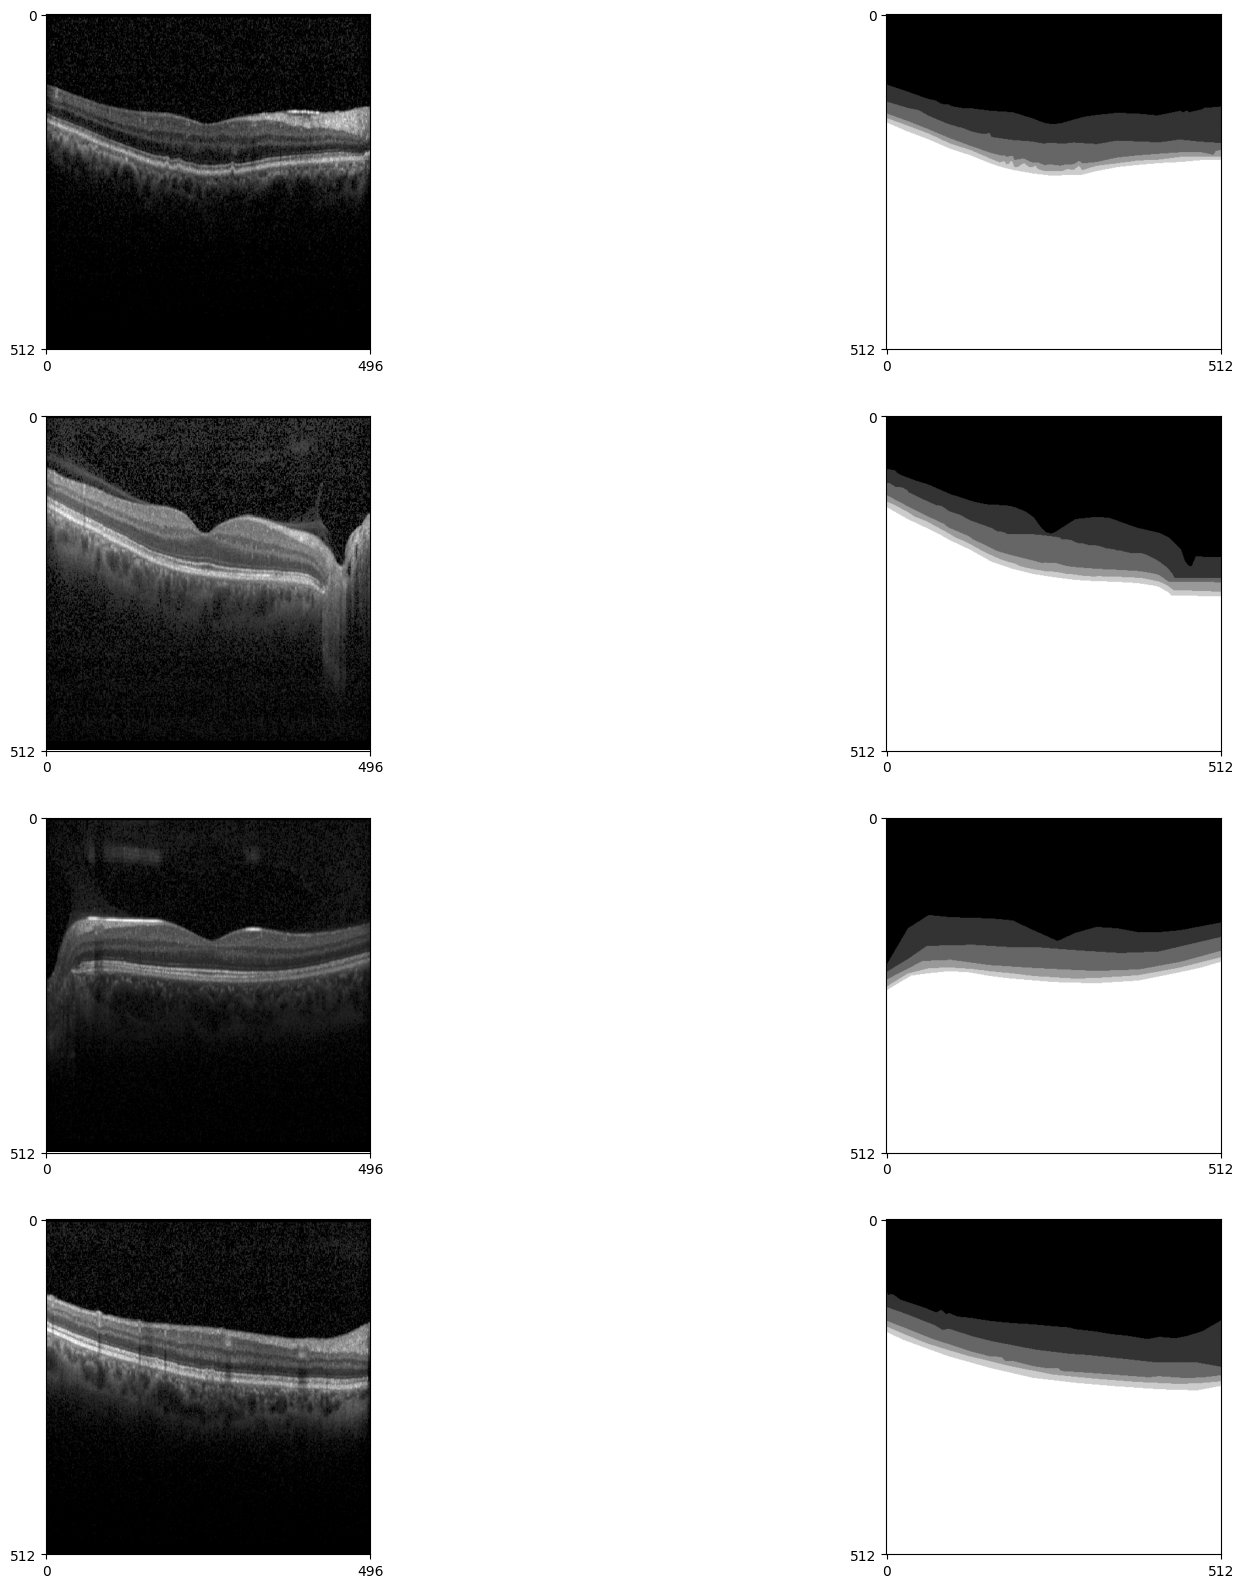

In [4]:
def plot_image_and_label(image, label, ax):
    ax[0].imshow(image.squeeze(0), cmap='gray')
    ax[0].set_xticks([0, image.shape[2]])
    ax[0].set_yticks([0, image.shape[1]])
    ax[1].imshow(label.squeeze(0), cmap='gray')
    ax[1].set_xticks([0, label.shape[2]])
    ax[1].set_yticks([0, label.shape[1]])


NUM_PLOTS = 4
fig, ax = plt.subplots(NUM_PLOTS,2, figsize=(20,20))

for i in range(NUM_PLOTS):
    randindex = random.randint(0, len(o)-1)
    image, label = o[randindex]

    plot_image_and_label(image, label, ax[i])

In [5]:
encoder_models = [
    'resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152'
]

In [6]:
# !pip install segmentation-models-pytorch
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",        # Choose your backbone
    encoder_weights="imagenet",     # Use pretrained weights
    in_channels=1,                  # 1 for grayscale OCT images
    classes=6,                      # Number of output classes (e.g., AMD, DME, Normal)
)

/home/polyester/Desktop/Programming/OCT-Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
model = model.to("cuda")

In [8]:
randindex = random.randint(0, len(o)-1)
print(randindex)
image, label = o[randindex]

1164


In [9]:
imagec = image.unsqueeze(0).to("cuda") # Add batch dimension

In [11]:
imagec.type()

'torch.cuda.ByteTensor'

In [10]:
out = model(imagec)

RuntimeError: Input type (torch.cuda.ByteTensor) and weight type (torch.cuda.FloatTensor) should be the same

In [ ]:
out.shape  # Should be [1, 6, H, W] where H and W are height and width of the input image

In [ ]:
def getwh(img):
	if len(img.shape) == 2:
		h, w = img.shape
	elif len(img.shape) == 3:
		h, w, _ = img.shape
	else:
		raise ValueError(f"Image shape is invalid {img.shape}")
	return w, h

def cvreadimg(path: Path):
	img = cv.imread(str(path))
	assert img is not None, "file could not be read, check with os.path.exists()"
	return img

def fill_corners(gray):
	w, h = getwh(gray)

	mask = np.zeros((h+2, w+2), dtype=np.uint8)
	corners = [(0, 0), (0, h - 1), (w - 1, 0), (w - 1, h - 1)]
	for corner_seed in corners:
		# Low and high brightness tolerance (e.g., 5-unit tolerance in each channel)
		lo_diff = (0, 0, 0)
		up_diff = (0, 0, 0)

		# Perform the flood fill
		# The function modifies the 'img' array in-place
		black_color = (0,0,0)
		cv.floodFill(
			gray, 
			mask, 
			corner_seed, 
			black_color, 
			loDiff=lo_diff, 
			upDiff=up_diff
		)
	return gray

def binary_cluster_calc_mean(img):
	y, x = np.where(img == 255)
	mean_coo = (int(np.mean(x)), int(np.mean(y)))

	w, h = getwh(img)
	middle_coo = (w/2, h/2)
	return mean_coo, middle_coo

def move2middle(img, segment): 
	mean_coo, middle_coo = binary_cluster_calc_mean(segment)
	translation_vector = (int(middle_coo[0] - mean_coo[0]), int(middle_coo[1] - mean_coo[1]))

	translation_matrix = np.float32([
		[1, 0, translation_vector[0]],
		[0, 1, translation_vector[1]]
	])

	w, h = getwh(img)
	
	black_color = (0,0,0)
	translated_img = cv.warpAffine(
		img, 
		translation_matrix, 
		(w, h),
		borderMode=cv.BORDER_CONSTANT, # Tells OpenCV to use a constant color
		borderValue=black_color          # Specifies the constant color (White)
	)
	return translated_img, mean_coo, middle_coo, translation_vector

def revertMove(img, translation_vector):
	translation_matrix = np.float32([
		[1, 0, -translation_vector[0]],
		[0, 1, -translation_vector[1]]
	])

	w, h = getwh(img)
	
	black_color = (0,0,0)
	translated_img = cv.warpAffine(
		img, 
		translation_matrix, 
		(w, h),
		borderMode=cv.BORDER_CONSTANT, # Tells OpenCV to use a constant color
		borderValue=black_color          # Specifies the constant color (White)
	)
	return translated_img

def simple_segmentation(img):
	gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
	corner_filled = fill_corners(gray.copy())
	

	def contrast_sigmoid(arr: np.ndarray, c, d=255/2, a=0,b=255):
		return ((b - a) / (1 + np.exp(-c*(arr.astype(np.float32) - d))) + a).astype(np.uint8)

	def contrast_linear(arr: np.ndarray,a,b):
		return (a*arr.astype(np.float32) + b).astype(np.uint8)
	
	alpha = 255 / (corner_filled.max()-corner_filled.min())
	beta = -alpha * corner_filled.min()

	gray_contrasted = contrast_linear(corner_filled, alpha, beta)

	# start segmentation
	_, thresh = cv.threshold(corner_filled,0,255,cv.THRESH_BINARY + cv.THRESH_OTSU)
	denoised = cv.medianBlur(thresh, 7)

	denoised_mv2middle, mean_coo, middle_coo, translation_vector = move2middle(denoised, denoised)

	kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (55,55))
	closing_mv2middle = cv.morphologyEx(denoised_mv2middle, cv.MORPH_CLOSE, kernel)

	further_denoised = cv.medianBlur(closing_mv2middle, 111)

	closing = revertMove(further_denoised, translation_vector)

	numLabels, labels, stats, centroids = cv.connectedComponentsWithStats(closing, connectivity=8, ltype=cv.CV_32S)

	print(stats, type(stats))
	if stats.shape[0] <= 1:
		# no segments found
		maxstats = np.array([0,0,0,0,0])
	else:
		maxstats = stats[stats[1:].argmax(axis=0)[-1] + 1]

	categories = np.arange(numLabels)
	values = stats[:,-1]

	top_left_coo = (maxstats[0], maxstats[1])
	area = (maxstats[2], maxstats[3])

	return (
		gray, 
		gray_contrasted, 
		corner_filled, 
		thresh, 
		denoised, 
		denoised_mv2middle, 
		closing_mv2middle, 
		closing, 
		top_left_coo, 
		area,
		categories,
		values,
	)

def plot(path: Path, ax, file_type, cls):
	img = cvreadimg(path)
	#cls = path.parent.name.split("_")[0]
	(
		gray, 
		gray_contrasted, 
		corner_filled, 
		thresh, 
		denoised, 
		denoised_mv2middle, 
		closing_mv2middle, 
		closing, 
		top_left_coo, 
		area,
		categories,
		values,
	) = simple_segmentation(img)
	#translated_img, mean_coo, middle_coo = move2middle(img, denoised)

	ax[0].set_title(f'{file_type}/{cls}/{path.name}')
	ax[0].imshow(img, cmap='gray')
	pixel_values = gray.flatten()
	#ax[1].set_title(f'{(gray == 0).sum()}, {(gray == 255).sum()}, {gray.min()}, {gray.max()}')
	ax[1].hist(
		pixel_values,
		bins=256,         # Use 256 bins for the 256 possible intensity values (0-255)
		range=[0, 256],   # Set the range of the x-axis
		color='gray',
		alpha=0.7
	)
	ax[1].set_xticks(
		[0, gray.min(), gray.max(), 255]
	)
	ax[2].imshow(corner_filled, cmap='gray')
	ax[3].imshow(gray_contrasted, cmap='gray')
	pixel_values_contrasted = gray_contrasted.flatten()
	#ax[4].set_title(
	#	f'{(gray_contrasted == 0).sum()}, {(gray_contrasted == 255).sum()}, {gray_contrasted.min()}, {gray_contrasted.max()}'
	#)
	ax[4].hist(
		pixel_values_contrasted,
		bins=256,         # Use 256 bins for the 256 possible intensity values (0-255)
		range=[0, 256],   # Set the range of the x-axis
		color='gray',
		alpha=0.7
	)
	ax[4].set_xticks(
		[0, gray_contrasted.min(), gray_contrasted.max(), 255]
	)
	ax[5].imshow(thresh, cmap='gray')
	ax[6].imshow(denoised, cmap='gray')
	ax[8].imshow(denoised_mv2middle, cmap='gray')
	ax[9].imshow(closing_mv2middle, cmap='gray')
	ax[10].imshow(closing, cmap='gray')

	rect = patches.Rectangle(
    	top_left_coo,  # (x, y) anchor point (bottom-left)
	    area[0],           # Width
	    area[1],          # Height
	    linewidth=2,
	    edgecolor='r',
	    facecolor='lightblue',
	    alpha=0.6,
	    label='Rectangle'
	)
	ax[10].add_patch(rect)

	pixel_values_closing = gray[closing == 0].flatten()
	ax[11].hist(
		pixel_values_closing,
		bins=256,         # Use 256 bins for the 256 possible intensity values (0-255)
		range=[0, 256],   # Set the range of the x-axis
		color='gray',
		alpha=0.7
	)

	ax[12].bar(categories, values, color='skyblue')

	#ax[5].plot(mean_coo[0], mean_coo[1], marker='o', color='red', markersize=5)
	#ax[5].plot(middle_coo[0], middle_coo[1], marker='o', color='blue', markersize=5)
	#ax[6].imshow(translated_img, cmap='gray')

In [ ]:
random.seed(42)
classes = ['DME', 'AMD', 'DRUSEN', 'DR', 'CNV', 'NORMAL', 'CSR', 'MH']
file_type = 'test'
fig, ax = plt.subplots(8, 13, figsize=(20,20))
for i, cls in enumerate(classes):
    path = random.choice(list(Path(f'OCTData/{file_type}/{cls}').iterdir()))
    plot(path, ax[i], file_type, cls)

In [ ]:
paths = [
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/test/DME/dme_test_1171.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/test/DME/dme_test_1203.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/val/AMD/amd_val_1310.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/train/DME/dme_train_2836.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/train/DME/dme_train_2976.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/train/DME/dme_train_2973.jpg'),
    Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/train/AMD/amd_train_1656.jpg'),
]

In [ ]:
fig, ax = plt.subplots(len(paths), 13, figsize=(20,20))
for i, path in enumerate(paths):
    plot(path, ax[i], "train", "DME")